# Neural Networks with PyTorch

In the previous notebook we built a neural network **from scratch** using only NumPy.  
Here we rebuild the same network using **PyTorch**, which handles the hard parts (gradient computation, GPU acceleration, data loading) automatically.

### NumPy → PyTorch equivalences

| What we did by hand (NumPy) | What PyTorch does for us |
|-----------------------------|--------------------------|
| `np.dot(A, W) + b` | `nn.Linear(in, out)` |
| `sigmoid(z)` | `nn.Sigmoid()` |
| `cross_entropy_loss(y_pred, y_true)` | `nn.CrossEntropyLoss()` |
| `backward()` (chain rule by hand) | `loss.backward()` (autograd) |
| `update_params()` (gradient descent) | `optimizer.step()` |
| Manual mini-batch loop | `DataLoader` |

### Learning objectives
- Understand `nn.Module` and how to define a model in PyTorch
- Use `DataLoader` for efficient batching
- Understand the 4-step PyTorch training loop
- Evaluate a model and inspect its learned weights

---
## 0. Imports

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import classification_report, confusion_matrix

# Confirm which device is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


---
## 1. Data Pipeline

PyTorch uses two abstractions for data:

- **`Dataset`** — knows *what* the data is and how to load one sample.
- **`DataLoader`** — wraps a Dataset and handles *batching*, *shuffling*, and *parallel loading*.

### Transforms
Transforms are applied to each image on-the-fly when a batch is loaded.

| Transform | Input | Output | Why |
|-----------|-------|--------|-----|
| `ToTensor()` | PIL image (H×W, uint8) | Tensor (1×H×W, float32 in [0,1]) | PyTorch works with tensors |
| `Normalize((0.5,),(0.5,))` | [0, 1] | [-1, 1] | Zero-centred inputs train more stably |

> **Formula:** `output = (input − mean) / std` → `(x − 0.5) / 0.5` maps [0,1] → [−1,1]

In [2]:
# Define the sequence of transforms applied to every image
transform = transforms.Compose([
    transforms.ToTensor(),                   # PIL → FloatTensor in [0, 1]
    transforms.Normalize((0.5,), (0.5,))     # rescale to [-1, 1]
])

# Download MNIST (only happens once; cached in ./data afterwards)
train_data = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoaders: handle batching and shuffling automatically
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=1000, shuffle=False)

print(f"Training samples : {len(train_data):,}")
print(f"Test samples     : {len(test_data):,}")
print(f"Batches per epoch: {len(train_loader)}  (batch size = 64)")

Training samples : 60,000
Test samples     : 10,000
Batches per epoch: 938  (batch size = 64)


### Visualise a batch
Let's inspect what the data looks like *after* the transforms are applied.

Batch tensor shape : torch.Size([64, 1, 28, 28])
  └─ (batch, channels, height, width) = (64, 1, 28, 28)
Pixel value range  : [-1.00, 1.00]  (after normalisation)


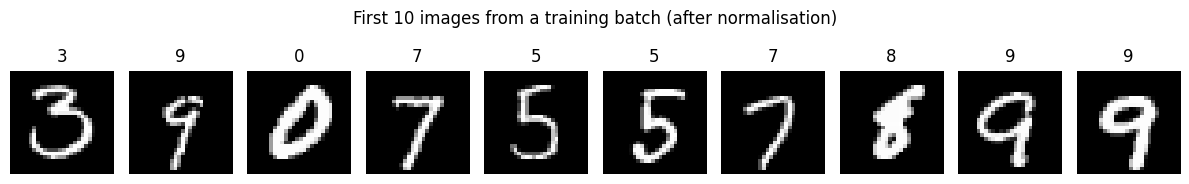

In [3]:
# Grab one batch from the training loader
sample_images, sample_labels = next(iter(train_loader))

print(f"Batch tensor shape : {sample_images.shape}")
print(f"  └─ (batch, channels, height, width) = {tuple(sample_images.shape)}")
print(f"Pixel value range  : [{sample_images.min():.2f}, {sample_images.max():.2f}]  (after normalisation)")

# Show the first 10 images
plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    # squeeze removes the channel dimension (1×28×28 → 28×28) for plotting
    plt.imshow(sample_images[i].squeeze(), cmap="gray")
    plt.title(str(sample_labels[i].item()))
    plt.axis("off")
plt.suptitle("First 10 images from a training batch (after normalisation)")
plt.tight_layout()
plt.show()

---
## 2. Model Architecture — `nn.Module`

Every PyTorch model is a class that inherits from `nn.Module`. You must implement two methods:

| Method | What to put inside |
|--------|--------------------|
| `__init__` | Define all layers as attributes (PyTorch registers them automatically) |
| `forward(x)` | Describe *how data flows* through those layers |

PyTorch's **autograd** engine traces every operation inside `forward()` and uses the computation graph to run `backward()` for you automatically.

### `nn.Linear` under the hood
`nn.Linear(in_features, out_features)` stores a weight matrix **W** (shape `out × in`) and a bias **b** (shape `out`), and computes:
$$\text{output} = x W^\top + b$$
This is identical to what we did with `np.dot(x, W) + b` — PyTorch just handles initialisation and gradient tracking.

### About `nn.CrossEntropyLoss`
This loss combines **softmax + negative log-likelihood** in one numerically stable step.  
Because of this, the model should return **raw logits** from `forward()` — **do NOT apply softmax yourself**.

In [4]:
class SimpleNN(nn.Module):
    """
    Fully-connected feed-forward neural network built with PyTorch.

    Architecture
    ------------
    Input  →  [Linear → Sigmoid]  ×  len(hidden_sizes)  →  Linear  →  logits

    The output layer returns raw logits (no softmax). PyTorch's
    nn.CrossEntropyLoss applies softmax internally, which is more
    numerically stable than doing it separately.

    Parameters
    ----------
    input_size   : number of input features (784 for MNIST 28×28)
    hidden_sizes : list of hidden layer widths — e.g. [128, 64]
                   works for any number of hidden layers
    output_size  : number of classes (10 for MNIST digits 0–9)
    """

    def __init__(self, input_size=784, hidden_sizes=[128, 64], output_size=10):
        super().__init__()

        # Build hidden layers dynamically using nn.ModuleList.
        # nn.ModuleList is like a Python list but PyTorch-aware:
        # it registers the contained layers so their parameters are tracked.
        layer_sizes = [input_size] + hidden_sizes
        self.hidden_layers = nn.ModuleList([
            nn.Linear(layer_sizes[i], layer_sizes[i + 1])
            for i in range(len(layer_sizes) - 1)
        ])

        # Separate output layer — no activation (raw logits for CrossEntropyLoss)
        self.output_layer = nn.Linear(hidden_sizes[-1], output_size)

        # Activation function shared by all hidden layers
        self.activation = nn.Sigmoid()

    def forward(self, x):
        """
        Define the forward pass.

        PyTorch's autograd traces every operation here and builds a
        computation graph used later by loss.backward().

        Parameters
        ----------
        x : Tensor of shape (batch, 1, 28, 28)  — raw images from DataLoader

        Returns
        -------
        logits : Tensor of shape (batch, 10)  — raw scores, one per class
        """
        # Flatten (batch, 1, 28, 28) → (batch, 784)
        # x.size(0) is the batch size; -1 infers the remaining dimensions
        x = x.view(x.size(0), -1)

        # Pass through each hidden layer with sigmoid activation
        for layer in self.hidden_layers:
            x = self.activation(layer(x))

        # Output layer: linear only — CrossEntropyLoss adds the softmax
        return self.output_layer(x)

### Inspect the architecture and parameter count

It's good practice to inspect your model *before* training to verify the shapes are what you expect.

In [5]:
model = SimpleNN(input_size=784, hidden_sizes=[64, 32], output_size=10).to(device)

print("Model architecture:")
print(model)

print("\nLayer-by-layer parameter shapes and counts:")
print(f"  {'Layer':<30} {'Shape':<20} {'Parameters':>12}")
print("  " + "-" * 64)
total_params = 0
for name, param in model.named_parameters():
    n = param.numel()  # total number of elements in this tensor
    print(f"  {name:<30} {str(tuple(param.shape)):<20} {n:>12,}")
    total_params += n
print(f"\n  Total trainable parameters: {total_params:,}")

Model architecture:
SimpleNN(
  (hidden_layers): ModuleList(
    (0): Linear(in_features=784, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=32, bias=True)
  )
  (output_layer): Linear(in_features=32, out_features=10, bias=True)
  (activation): Sigmoid()
)

Layer-by-layer parameter shapes and counts:
  Layer                          Shape                  Parameters
  ----------------------------------------------------------------
  hidden_layers.0.weight         (64, 784)                  50,176
  hidden_layers.0.bias           (64,)                          64
  hidden_layers.1.weight         (32, 64)                    2,048
  hidden_layers.1.bias           (32,)                          32
  output_layer.weight            (10, 32)                      320
  output_layer.bias              (10,)                          10

  Total trainable parameters: 52,650


---
## 3. Training

### Loss function — `nn.CrossEntropyLoss`
Combines softmax + negative log-likelihood in one step.  
Expects **logits** (raw scores) as input and **integer class indices** as targets.

### Optimiser — `optim.SGD`
Stochastic Gradient Descent updates parameters with:
$$\theta \leftarrow \theta - \eta \, \nabla_\theta \mathcal{L}$$

### The 4-step PyTorch training loop
Every mini-batch update follows the same four steps:

```
1. optimizer.zero_grad()   ← clear gradients from the previous batch
2. outputs = model(inputs) ← forward pass
3. loss.backward()         ← backpropagation (autograd computes all gradients)
4. optimizer.step()        ← update all parameters
```

> **Why zero_grad()?** By default PyTorch *accumulates* gradients across calls to `.backward()`.  
> Forgetting `zero_grad()` is one of the most common PyTorch bugs — gradients pile up and training diverges.

In [6]:
# Loss: CrossEntropyLoss = softmax + NLL — expects raw logits + integer targets
criterion = nn.CrossEntropyLoss()

# Optimiser: vanilla SGD with learning rate 0.1
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [7]:
epochs = 50
loss_history       = []
epoch_time_history = []   # seconds spent on each epoch

# model.train() tells PyTorch we are in training mode.
# This matters for layers like Dropout or BatchNorm that behave
# differently during training vs. evaluation.
model.train()

total_start = time.time()   # start the overall training timer

for epoch in range(epochs):
    epoch_start  = time.time()   # start the per-epoch timer
    running_loss = 0.0

    for inputs, labels in train_loader:
        # Move data to the same device as the model (CPU or GPU)
        inputs, labels = inputs.to(device), labels.to(device)

        # ── Step 1: Clear accumulated gradients from the previous batch ──────
        optimizer.zero_grad()

        # ── Step 2: Forward pass — compute predictions ────────────────────────
        outputs = model(inputs)              # shape: (batch, 10) — raw logits

        # ── Step 3: Compute loss and backpropagate ────────────────────────────
        loss = criterion(outputs, labels)    # scalar loss value
        loss.backward()                      # autograd fills .grad for every param

        # ── Step 4: Update parameters using the computed gradients ────────────
        optimizer.step()

        running_loss += loss.item()

    avg_loss   = running_loss / len(train_loader)
    epoch_time = time.time() - epoch_start   # seconds this epoch took

    loss_history.append(avg_loss)
    epoch_time_history.append(epoch_time)

    print(f"Epoch {epoch+1:>3}/{epochs}  |  Loss: {avg_loss:.4f}  |  Time: {epoch_time:.2f}s")

total_time = time.time() - total_start
print(f"\nTotal training time : {total_time:.2f}s  "
      f"({total_time/60:.2f} min)  —  "
      f"avg {total_time/epochs:.2f}s / epoch")

Epoch   1/50  |  Loss: 1.5928  |  Time: 2.38s
Epoch   2/50  |  Loss: 0.5499  |  Time: 2.36s
Epoch   3/50  |  Loss: 0.3634  |  Time: 2.26s
Epoch   4/50  |  Loss: 0.2934  |  Time: 2.33s
Epoch   5/50  |  Loss: 0.2486  |  Time: 2.27s
Epoch   6/50  |  Loss: 0.2143  |  Time: 2.34s
Epoch   7/50  |  Loss: 0.1886  |  Time: 2.31s
Epoch   8/50  |  Loss: 0.1682  |  Time: 2.31s
Epoch   9/50  |  Loss: 0.1523  |  Time: 2.35s
Epoch  10/50  |  Loss: 0.1388  |  Time: 2.41s
Epoch  11/50  |  Loss: 0.1284  |  Time: 2.47s
Epoch  12/50  |  Loss: 0.1185  |  Time: 2.34s
Epoch  13/50  |  Loss: 0.1108  |  Time: 2.34s
Epoch  14/50  |  Loss: 0.1045  |  Time: 2.34s
Epoch  15/50  |  Loss: 0.0982  |  Time: 2.27s
Epoch  16/50  |  Loss: 0.0928  |  Time: 2.35s
Epoch  17/50  |  Loss: 0.0878  |  Time: 2.38s
Epoch  18/50  |  Loss: 0.0832  |  Time: 2.42s
Epoch  19/50  |  Loss: 0.0789  |  Time: 2.28s
Epoch  20/50  |  Loss: 0.0754  |  Time: 2.25s
Epoch  21/50  |  Loss: 0.0719  |  Time: 2.26s
Epoch  22/50  |  Loss: 0.0687  |  

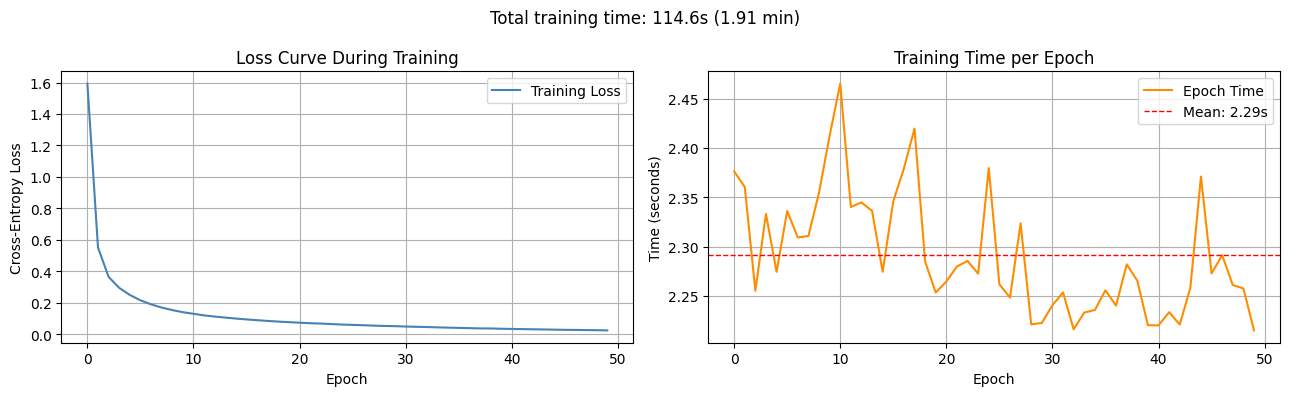

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: Loss curve ─────────────────────────────────────────────────────────
ax1.plot(loss_history, color='steelblue', label='Training Loss')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_title("Loss Curve During Training")
ax1.legend()
ax1.grid(True)

# ── Right: Per-epoch time ────────────────────────────────────────────────────
ax2.plot(epoch_time_history, color='darkorange', label='Epoch Time')
ax2.axhline(
    y=sum(epoch_time_history) / len(epoch_time_history),
    color='red', linestyle='--', linewidth=1,
    label=f"Mean: {sum(epoch_time_history)/len(epoch_time_history):.2f}s"
)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Time (seconds)")
ax2.set_title("Training Time per Epoch")
ax2.legend()
ax2.grid(True)

plt.suptitle(
    f"Total training time: {sum(epoch_time_history):.1f}s "
    f"({sum(epoch_time_history)/60:.2f} min)",
    fontsize=12
)
plt.tight_layout()
plt.show()

---
## 4. Evaluation

Two important PyTorch conventions for evaluation:

| Call | What it does |
|------|--------------|
| `model.eval()` | Switches layers like Dropout/BatchNorm to inference mode |
| `torch.no_grad()` | Disables autograd — no computation graph is built, saving memory and time |

Always use both together when you are **not** training.

In [9]:
model.eval()   # switch to evaluation mode

y_true, y_pred = [], []

with torch.no_grad():  # no gradients needed — faster and uses less memory
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        logits = model(inputs)                             # (batch, 10)

        # argmax over class dimension → predicted class index for each sample
        predictions = torch.argmax(logits, dim=1).cpu().numpy()

        y_pred.extend(predictions)
        y_true.extend(labels.numpy())  # labels stay on CPU — no .to(device) needed

print("Classification Report (test set):")
print(classification_report(y_true, y_pred, digits=4))

Classification Report (test set):
              precision    recall  f1-score   support

           0     0.9798    0.9888    0.9843       980
           1     0.9860    0.9912    0.9886      1135
           2     0.9740    0.9806    0.9773      1032
           3     0.9771    0.9723    0.9747      1010
           4     0.9726    0.9756    0.9741       982
           5     0.9773    0.9664    0.9718       892
           6     0.9760    0.9770    0.9765       958
           7     0.9802    0.9630    0.9715      1028
           8     0.9538    0.9754    0.9645       974
           9     0.9708    0.9564    0.9636      1009

    accuracy                         0.9749     10000
   macro avg     0.9748    0.9747    0.9747     10000
weighted avg     0.9749    0.9749    0.9749     10000



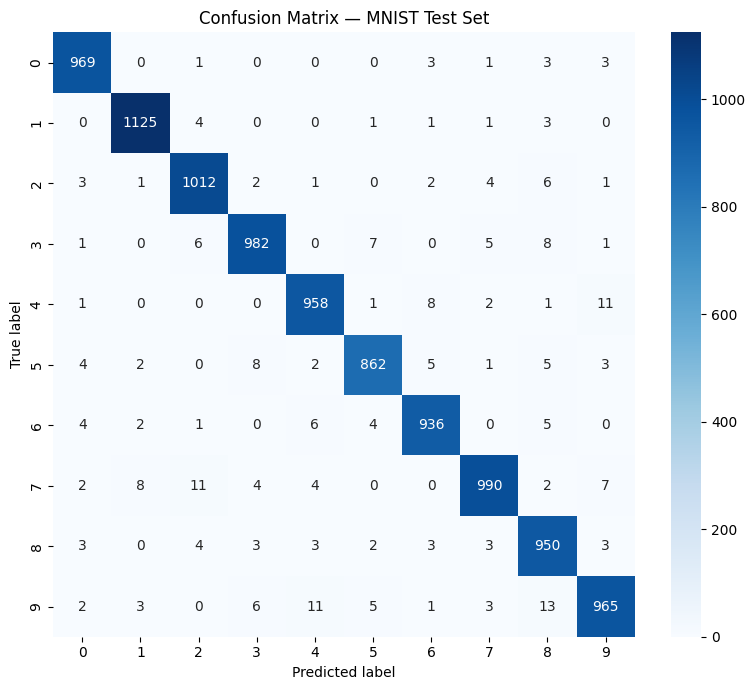

In [10]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=range(10), yticklabels=range(10)
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — MNIST Test Set")
plt.tight_layout()
plt.show()

# Reading the matrix: rows = true digit, columns = predicted digit.
# Diagonal = correct predictions. Off-diagonal entries are mistakes.
# Common confusions: 4↔9, 3↔5, 7↔1

---
## 5. Inspecting Learned Weights

Every `nn.Linear` layer stores two tensors:
- `weight` — shape `(out_features, in_features)` — the **W** matrix
- `bias`   — shape `(out_features,)`             — the **b** vector

After training, we can visualise the first-layer weights as 28×28 images.  
Each row of `fc.weight` is a **filter** that the neuron learned to respond to.

In [11]:
# Print all parameter tensor names and shapes
print("Trained parameter shapes:")
for name, param in model.named_parameters():
    print(f"  {name:<40} {tuple(param.shape)}")

Trained parameter shapes:
  hidden_layers.0.weight                   (64, 784)
  hidden_layers.0.bias                     (64,)
  hidden_layers.1.weight                   (32, 64)
  hidden_layers.1.bias                     (32,)
  output_layer.weight                      (10, 32)
  output_layer.bias                        (10,)


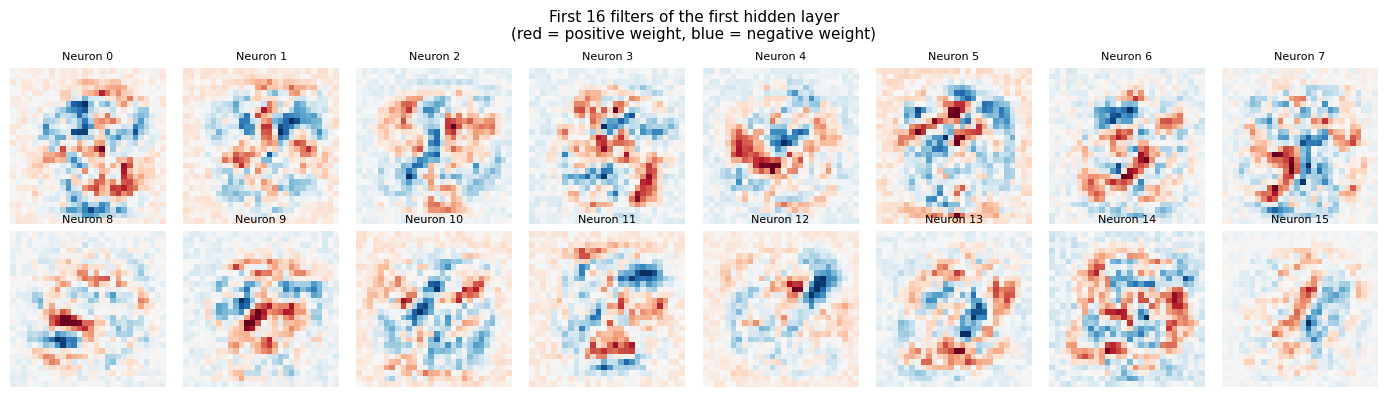

Weight value range: [-0.948, 1.014]


In [12]:
# Visualise the first 16 filters from the first hidden layer.
# Each filter has 784 values — one per input pixel — so we reshape to 28×28.
first_layer_weights = model.hidden_layers[0].weight.data.cpu().numpy()  # (128, 784)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    # Reshape the i-th filter to 28×28 and normalise for display
    w = first_layer_weights[i].reshape(28, 28)
    ax.imshow(w, cmap='RdBu', vmin=-w.max(), vmax=w.max())
    ax.set_title(f"Neuron {i}", fontsize=8)
    ax.axis("off")

plt.suptitle(
    "First 16 filters of the first hidden layer\n"
    "(red = positive weight, blue = negative weight)",
    fontsize=11
)
plt.tight_layout()
plt.show()

print(f"Weight value range: [{first_layer_weights.min():.3f}, {first_layer_weights.max():.3f}]")